# Figure 4: Drake Passage section velocity

Plots the zonal velocity through Drake Passage (at 69W) and the total
transport through the passage when a `volcello` file is available.

Russell, J.L., et al. (2018), Metrics for the evaluation of the Southern Ocean in coupled climate models and earth system models, *J. Geophysical Research - Oceans*, 123, 3120-3143, [doi:10.1002/2017JC013461](https://doi.org/10.1002/2017JC013461).

---

### About these notebooks

This notebook is one of a set reproducing the figures of Russell et al.
(2018), a suite of metrics for evaluating the Southern Ocean in coupled
climate and earth system models.

They are a Python translation of the NCL diagnostics distributed with
[ESMValTool](https://github.com/ESMValGroup/ESMValTool)
(`esmvaltool/diag_scripts/russell18jgr/`, driven by
`recipe_russell18jgr.yml`), rewritten so that each figure stands alone
and can be run interactively without going through a recipe.

Translated and maintained by **Romain Beucher**,
[ACCESS-NRI](https://www.access-nri.org.au).
Please contact <romain.beucher@anu.edu.au> with any questions.

## Scientific background

Drake Passage is the narrowest constriction through which the Antarctic
Circumpolar Current must pass, which makes the volume transport there
the standard single measure of ACC strength. Observational estimates
range from roughly 130 to 175 Sv depending on the method and period.

The section shows the vertical and meridional structure of the flow, not
only its total, because a model can produce a plausible total transport
from an unrealistic velocity distribution. The net transport quoted
above each panel needs a `volcello` file; without one the section is
still plotted.

## Setup

This notebook is standalone: everything it needs is defined below.  It
requires `esmvalcore`, `iris`, `numpy`, `matplotlib` and `cartopy` -
the full ESMValTool is *not* needed.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import BoundaryNorm, ListedColormap

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

## Helper functions

The helpers below are the parts of the original NCL diagnostic that are
worth keeping out of the way of the plotting code.  They are defined
here rather than imported so the notebook stands on its own.

In [2]:
import iris


# Constants used by the original NCL scripts
EARTH_RADIUS = 6.37e06   # m
DEG2RAD = 0.0174533


def coord_1d_or_2d(cube, axis):
    """Latitude/longitude points, which may be 1D or 2D.

    ESMValTool preprocessed ocean files carry either 1D dimension
    coordinates (regular grids) or 2D auxiliary coordinates
    (curvilinear grids); this hides the difference.
    """
    return np.asarray(cube.coord(axis).points)


def lat_1d(cube):
    """A representative 1D latitude array (column 0 for 2D grids)."""
    lat = coord_1d_or_2d(cube, "latitude")
    return lat[:, 0] if lat.ndim == 2 else lat


def lon_1d(cube):
    """A representative 1D longitude array (row 0 for 2D grids)."""
    lon = coord_1d_or_2d(cube, "longitude")
    return lon[0, :] if lon.ndim == 2 else lon


def closest_index(value, array):
    """Index of the array element closest to value (NCL closest_val)."""
    array = np.asarray(array, dtype=float)
    return int(np.nanargmin(np.abs(array - value)))


def time_mean(cube):
    """Average over the time dimension, if there is one."""
    if any(c.name() == "time" for c in cube.coords()):
        if cube.coord("time").shape[0] > 1:
            return cube.collapsed("time", iris.analysis.MEAN)
    return cube

## Dask cluster

Start a local cluster so the preprocessor can work in parallel.  On
Gadi, size this to the resources of your ARE session / PBS job.

In [3]:
from dask.distributed import Client

client = Client()
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 41129 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/41129/status,
Dashboard: /proxy/41129/status,Workers: 7
Total threads: 14,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:45135,Workers: 0
Dashboard: /proxy/41129/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:43611,Total threads: 2
Dashboard: /proxy/35287/status,Memory: 9.00 GiB
Nanny: tcp://127.0.0.1:40225,


## Datasets

Datasets are declared directly with `esmvalcore.dataset.Dataset`, so
this notebook does not need a recipe.  A small subset of the models of
the paper is used to keep the notebook quick; add entries to the
dictionary below to include more.

On Gadi the CMIP5 data comes from the `al33` and `rr3` projects - make
sure both are in the `storage` flags of your session.

In [4]:
from esmvalcore.dataset import Dataset

uo_datasets = {
    "ACCESS1-0": Dataset(
        short_name="uo",
        project="CMIP5",
        mip="Omon",
        exp="historical",
        ensemble="r1i1p1",
        dataset="ACCESS1-0",
        timerange="19860101/20051231",
    ),
    "CanESM2": Dataset(
        short_name="uo",
        project="CMIP5",
        mip="Omon",
        exp="historical",
        ensemble="r1i1p1",
        dataset="CanESM2",
        timerange="19860101/20051231",
    ),
}

volcello_datasets = {
    "ACCESS1-0": Dataset(
        short_name="volcello",
        project="CMIP5",
        mip="fx",
        exp="historical",
        ensemble="r0i0p0",
        dataset="ACCESS1-0",
        timerange="19860101/20051231",
    ),
    "CanESM2": Dataset(
        short_name="volcello",
        project="CMIP5",
        mip="fx",
        exp="historical",
        ensemble="r0i0p0",
        dataset="CanESM2",
        timerange="19860101/20051231",
    ),
}

<details>
<summary>Using ACCESS (CMIP6) models instead</summary>

The figures of the paper are CMIP5.  To evaluate an ACCESS model,
switch `project` to `CMIP6`, use a CMIP6 ensemble/grid label and the
CMIP6 variable names, e.g.

```python
Dataset(
    short_name="thetao", project="CMIP6", mip="Omon", exp="historical",
    ensemble="r1i1p1f1", grid="gn", dataset="ACCESS-ESM1-5",
    timerange="19860101/20051231",
)
```

Note the CMIP6 renaming of some variables (`sic` -> `siconc`,
`tauuo` is not always published) and that `volcello` and `areacello`
moved from `fx` to `Ofx`.
</details>

## Preprocessing

This diagnostic works on the raw data (no preprocessor is applied), so
the cubes are only loaded here.  The time average is taken as part of
the diagnostic.

In [5]:
def preprocess(cube):
    """No preprocessing is applied for this figure."""
    return cube


uo_cubes = {name: preprocess(dataset.load()) for name, dataset in uo_datasets.items()}
volcello_cubes = {name: dataset.load() for name, dataset in volcello_datasets.items()}

uo_cubes

{'ACCESS1-0': <iris 'Cube' of sea_water_x_velocity / (m s-1) (time: 240; depth: 50; cell index along second dimension: 300; cell index along first dimension: 360)>,
 'CanESM2': <iris 'Cube' of sea_water_x_velocity / (m s-1) (time: 240; depth: 40; latitude: 192; longitude: 256)>}

## Diagnostic

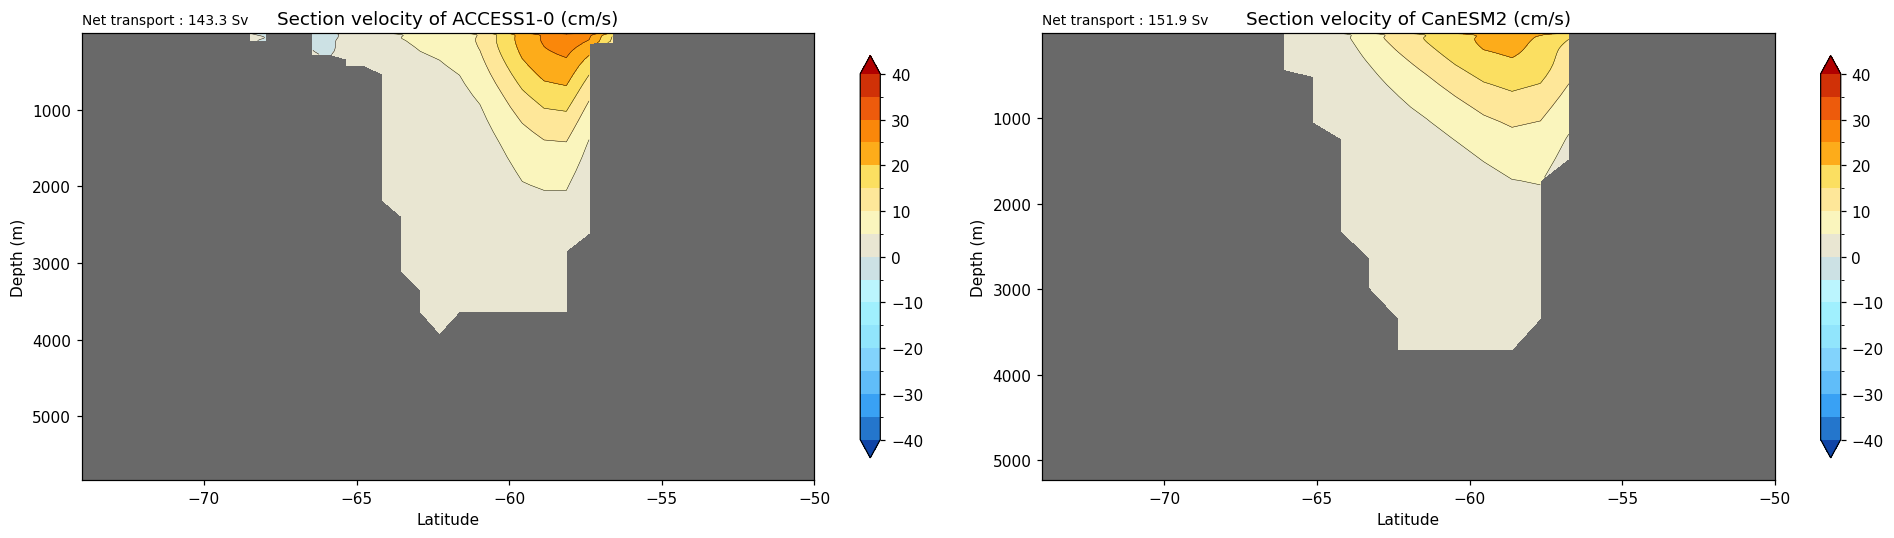

2026-09-22 08:24:51,193 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
Traceback (most recent call last):
2026-09-22 08:24:51,195 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/asyncio/runners.py", line 118, in run
    return self._loop.run_until_complete(task)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/asyncio/base_events.py", line 691, in run_until_complete
    return future.result()
           ^^^^^^^^^^^^^^^
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/site-packages/distributed/nanny.py", line 985, in run
    await worker.finished()
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/site-packages/distributed/core.py", line 494, in finished
    awai

In [6]:
# colour table of the original diagnostic
colors = np.array([
    [15.0, 69, 168], [36, 118, 205], [57, 162, 245], [96, 190, 250],
    [131, 212, 253], [146, 230, 253], [161, 241, 255], [188, 246, 255],
    [205, 226, 229], [234, 231, 211], [251, 246, 190], [255, 232, 154],
    [252, 224, 97], [254, 173, 26], [251, 136, 10], [238, 91, 12],
    [209, 49, 7], [178, 0, 0]]) / 256.0
levels = np.arange(-40.0, 40.1, 5.0)
cmap = ListedColormap(colors)
norm = BoundaryNorm(levels, ncolors=cmap.N, extend="both")

fig, axs = plt.subplots(1, len(uo_cubes), figsize=(9 * len(uo_cubes), 5),
                        squeeze=False)

for iplot, (name, cube) in enumerate(uo_cubes.items()):
    mean = time_mean(cube)
    lon, lat = lon_1d(mean), lat_1d(mean)
    lev = mean.coord(axis="Z").points

    # column closest to 69W (291E)
    a = (closest_index(291.0, lon) if np.max(lon) > 291.0
         else closest_index(-69.0, lon))
    section = np.ma.masked_invalid(mean.data[:, :, a])
    b1, b2 = closest_index(-76.0, lat), closest_index(-48.0, lat)

    # net transport from volcello, if available
    transport = None
    if name in volcello_cubes:
        vol = volcello_cubes[name]
        vol_lev = vol.coord(axis="Z").points
        # volcello / east-west grid distance = cross-section area
        dlon = abs(lon[a] - lon[a + 1]) * EARTH_RADIUS * DEG2RAD
        area = np.ma.masked_invalid(vol.data) / dlon
        area_2d = (area[::-1, :, a] if abs(vol_lev[0]) > abs(vol_lev[1])
                   else area[:, :, a])
        per_lat = (section * area_2d / 1.0e6).sum(axis=0)
        # compensate for the changing horizontal distance with latitude
        per_lat = per_lat / np.cos(lat * DEG2RAD)
        transport = float(per_lat[b1:b2 + 1].sum())

    ax = axs.flat[iplot]
    velocity = section[:, b1:b2 + 1] * 100.0        # m/s -> cm/s
    filled = ax.contourf(lat[b1:b2 + 1], lev, velocity, levels=levels,
                         cmap=cmap, norm=norm, extend="both")
    ax.contour(lat[b1:b2 + 1], lev, velocity, levels=levels,
               colors="black", linewidths=0.3)
    ax.set_facecolor("dimgrey")
    ax.set_xlim(-74, -50)
    ax.invert_yaxis()
    ax.set_xlabel("Latitude")
    ax.set_ylabel("Depth (m)")
    ax.set_title(f"Section velocity of {name} (cm/s)")
    ax.text(0.0, 1.02,
            "no volcello" if transport is None
            else f"Net transport : {transport:4.1f} Sv",
            transform=ax.transAxes, fontsize=9)
    fig.colorbar(filled, ax=ax, shrink=0.9)

plt.tight_layout()
plt.show()

**Figure 4: Drake Passage section velocity:** Zonal velocity (cm/s) through Drake Passage. The net transport quoted
above each panel is the sum between 75S and 49S of velocity times the
east-west cross-section area of each cell.